<a href="https://colab.research.google.com/github/DarthRevan7/ML_4_VIsion_-_Multimedia/blob/main/LogoFewShotDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LogoNet: Zero-Shot Logo Retrieval tramite Deep Siamese Networks

## 1. Introduzione
Il presente progetto affronta il problema del **Logo Retrieval** in uno scenario **Zero-Shot**. L'obiettivo è sviluppare un sistema capace di identificare brand mai visti durante la fase di addestramento, apprendendo una proiezione metrica in uno spazio latente dove immagini dello stesso brand risultano vicine secondo la distanza Euclidea.

## 2. Architettura del Sistema
Il framework si basa su una **Siamese ResNet-50**:
- **Backbone**: ResNet-50 pre-addestrata su ImageNet-1K, utilizzata come estrattore di feature.
- **Embedding Head**: Il layer fully-connected finale è stato sostituito per produrre un vettore di embedding di dimensione 2048.
- **Normalizzazione**: Viene applicata una normalizzazione L2 sugli embedding per garantire stabilità durante il calcolo della Triplet Loss.

## 3. Metodologia di Addestramento
L'apprendimento avviene tramite **Episodic Training** utilizzando la **Triplet Margin Loss**:
- **Triplet Selection**: Per ogni immagine *Anchor*, viene selezionata un'immagine *Positive* (stesso brand) e una *Negative* (brand differente).
- **Loss Function**: Si minimizza la distanza (Anchor, Positive) e si massimizza la distanza (Anchor, Negative) con un margine prefissato ($m=0.2$).
- **Optimizer**: Adam con learning rate di $2.5 \times 10^{-4}$ e weight decay per prevenire l'overfitting.

## 4. Protocollo di Valutazione
Per testare la capacità di generalizzazione, il dataset viene diviso in modalità **Class-Disjoint** (i brand del test set non sono presenti nel training set).

### Metriche di Retrieval
Il sistema viene valutato tramite un setup **Query vs Gallery**:
- **Query Set**: Una singola immagine per ogni brand ignoto.
- **Gallery Set**: Tutte le restanti immagini dei brand di test.
- **Indicatori**: Precision@K (P@K) e Recall@K (R@K) per $K \in \{1, 5, 10\}$.

## 5. Istruzioni per l'Esecuzione
1. **Setup Drive**: Montare Google Drive e assicurarsi che la cartella `Progetto_ML_Team` contenga i dataset `LogoDet-3K` e `FlickrLogos32.v1i.voc`.
2. **Preprocessing**: Eseguire le celle della **Parte 1** per inizializzare i loader e i sampler delle triplette.
3. **Training**: Eseguire la sezione **Architettura** e **Training** per addestrare il modello e salvare i pesi (`logonet_triplet.pth`).
4. **Inference**: Eseguire la cella **EVAL FINALE** per calcolare gli embedding e visualizzare le metriche di retrieval.

## 6. Dataset Utilizzati
- **LogoDet-3K**: Utilizzato per il training su larga scala e la valutazione zero-shot.
- **FlickrLogos32**: Utilizzato come benchmark esterno per testare la robustezza del modello su domini differenti.

In [28]:
import os
from google.colab import drive

# 1. Monta Google Drive
drive.mount('/content/drive')

# --- CONFIGURAZIONE ---
nome_cartella_progetto = "Progetto_ML_Team"
# ----------------------

# 2. Costruisce il percorso CORRETTO
base_path = f"/content/drive/MyDrive/{nome_cartella_progetto}"

# 3. Verifica di sicurezza
if os.path.exists(base_path):
    print(f"✅ Tutto ok! Percorso impostato su: {base_path}")
    os.chdir(base_path)
else:
    print(f"❌ Errore: Non trovo la cartella '{nome_cartella_progetto}'")
    print("Assicurati di aver creato la scorciatoia in 'Il mio Drive' come spiegato nel Passo 1.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Tutto ok! Percorso impostato su: /content/drive/MyDrive/Progetto_ML_Team


In [ ]:
# ==============================================================================
# --------------------------- PART 1: DATABASE ---------------------------------
# ==============================================================================

import os
import glob
import random
import xml.etree.ElementTree as ET
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

def crop_logo(image_path, bbox):
    """
    Legge un'immagine e la ritaglia basandosi sulla bounding box.
    bbox si aspetta una tupla/lista: (x_min, y_min, x_max, y_max)
    """
    try:
        img = Image.open(image_path).convert("RGB")
        cropped_img = img.crop(bbox)
        return cropped_img
    except Exception as e:
        print(f"Errore nel processare l'immagine {image_path}: {e}")
        return None

class LogoDataset(Dataset):
    def __init__(self, root_dir, split="train", transform=None, split_ratio=0.8):
        self.root_dir = root_dir
        self.split = split
        self.transform = transform

        self.image_paths = []
        self.bboxes = []
        self.labels = []

        print(f"Inizializzazione LogoDataset in modalità: {split.upper()}...")

        # 1. Raccogliamo tutti i brand disponibili navigando nelle categorie
        all_brands = []
        if not os.path.exists(root_dir):
            raise ValueError(f"Cartella non trovata: {root_dir}")

        categorie = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
        for cat in categorie:
            cat_path = os.path.join(root_dir, cat)
            brands = [d for d in os.listdir(cat_path) if os.path.isdir(os.path.join(cat_path, d))]
            for b in brands:
                all_brands.append((cat, b))

        # 2. Ordiniamo e mescoliamo con un seed fisso per riproducibilità
        all_brands.sort()
        random.seed(42)
        random.shuffle(all_brands)

        # 3. Applichiamo lo split Class-Disjoint
        split_idx = int(len(all_brands) * split_ratio)
        if self.split == "train":
            selected_brands = all_brands[:split_idx]
        else: # "test"
            selected_brands = all_brands[split_idx:]

        print(f"Selezionati {len(selected_brands)} brand per il set di {split}.")

        # 4. Estraiamo percorsi immagini e coordinate XML
        for cat, brand in selected_brands:
            brand_path = os.path.join(root_dir, cat, brand)
            xml_files = glob.glob(os.path.join(brand_path, "*.xml"))

            for xml_file in xml_files:
                try:
                    tree = ET.parse(xml_file)
                    root = tree.getroot()
                    bndbox = root.find('.//bndbox')

                    if bndbox is not None:
                        xmin = int(float(bndbox.find('xmin').text))
                        ymin = int(float(bndbox.find('ymin').text))
                        xmax = int(float(bndbox.find('xmax').text))
                        ymax = int(float(bndbox.find('ymax').text))

                        # Assumiamo che l'immagine abbia lo stesso nome dell'XML
                        base_name = os.path.splitext(os.path.basename(xml_file))[0]

                        # Cerchiamo l'immagine corrispondente (.jpg, .jpeg o .png)
                        img_path = None
                        for ext in ['.jpg', '.jpeg', '.png']:
                            temp_path = os.path.join(brand_path, base_name + ext)
                            if os.path.exists(temp_path):
                                img_path = temp_path
                                break

                        if img_path:
                            self.image_paths.append(img_path)
                            self.bboxes.append((xmin, ymin, xmax, ymax))
                            self.labels.append(brand)
                except Exception as e:
                    pass # Ignora file corrotti o formattati male

        print(f"Caricamento completato: {len(self.image_paths)} immagini trovate.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        bbox = self.bboxes[idx]
        label = self.labels[idx]

        img = crop_logo(img_path, bbox)

        if self.transform:
            img = self.transform(img)

        return img, label

⏳ Avvio il test sul dataset di training...
Inizializzazione LogoDataset in modalità: TRAIN...
Selezionati 7 brand per il set di train.
Caricamento completato: 682 immagini trovate.

✅ Successo! Il dataset di training contiene 682 loghi ritagliati.

🖼️ Estrazione casuale (Indice 558):
🏷️ Brand: 76
📏 Dimensioni del crop: (327, 208)


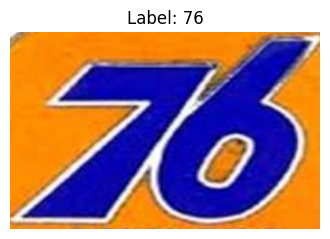

In [ ]:
# ==============================================================================
# --- CELLA DI TEST: VERIFICA FUNZIONAMENTO LOGODATASET ---
# ==============================================================================

import matplotlib.pyplot as plt
import random
import os

# Ricostruiamo il percorso del dataset
dataset_path = os.path.join(base_path, "LogoDet-3K")

print("⏳ Avvio il test sul dataset di training...")

# 1. Istanziamo il nostro dataset in modalità train
try:
    train_dataset = LogoDataset(root_dir=dataset_path, split="train", split_ratio=0.8)
    print(f"\n✅ Successo! Il dataset di training contiene {len(train_dataset)} loghi ritagliati.")

    # 2. Peschiamo un'immagine a caso per verificare il cropping
    if len(train_dataset) > 0:
        idx = random.randint(0, len(train_dataset) - 1)
        img, label = train_dataset[idx]

        print(f"\n🖼️ Estrazione casuale (Indice {idx}):")
        print(f"🏷️ Brand: {label}")
        print(f"📏 Dimensioni del crop: {img.size}")

        # 3. Mostriamo l'immagine a schermo
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.title(f"Label: {label}")
        plt.axis('off')
        plt.show()
    else:
        print("\n⚠️ Errore: Il dataset risulta vuoto. Controlla che i file XML e le immagini siano al posto giusto.")

except Exception as e:
    print(f"\n❌ Si è verificato un errore durante il test: {e}")

In [ ]:
# ==============================================================================
# --- PARTE 1.2: TRIPLET SAMPLER (Generazione Episodi per Siamese Network) ---
# ==============================================================================

import random
from torch.utils.data import Dataset

class TripletLogoDataset(Dataset):
    """
    Wrapper che prende un Dataset standard e restituisce Triplette:
    (Anchor, Positive, Negative)
    """
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

        print("⚙️ Inizializzazione Triplet Sampler...")

        # 1. Creiamo un dizionario per raggruppare gli indici delle immagini per brand.
        # Questo ci permette di pescare velocemente immagini Positive e Negative.
        self.label_to_indices = {}
        for idx, label in enumerate(self.base_dataset.labels):
            if label not in self.label_to_indices:
                self.label_to_indices[label] = []
            self.label_to_indices[label].append(idx)

        # Lista di tutti i brand disponibili (utile per pescare i Negative)
        self.labels_list = list(self.label_to_indices.keys())

        print(f"✅ Sampler pronto: indicizzati {len(self.labels_list)} brand univoci.")

    def __len__(self):
        """La lunghezza del dataset a triplette è uguale a quella del dataset base."""
        return len(self.base_dataset)

    def __getitem__(self, idx):
        """
        Genera dinamicamente una tripletta partendo da un indice.
        """
        # --- 1. ANCHOR ---
        # Prendiamo l'immagine di riferimento usando l'indice richiesto
        anchor_img, anchor_label = self.base_dataset[idx]

        # --- 2. POSITIVE ---
        # Cerchiamo tutti gli indici delle immagini che hanno lo stesso brand dell'Anchor
        positive_indices = self.label_to_indices[anchor_label]

        # Scegliamo a caso un'immagine positiva, assicurandoci (se possibile)
        # che non sia la stessa identica immagine dell'Anchor
        if len(positive_indices) > 1:
            pos_idx = random.choice([i for i in positive_indices if i != idx])
        else:
            pos_idx = idx # Fallback di sicurezza: se c'è solo 1 immagine per quel brand, usiamo quella

        positive_img, _ = self.base_dataset[pos_idx]

        # --- 3. NEGATIVE ---
        # Scegliamo a caso un brand diverso da quello dell'Anchor
        negative_label = random.choice([l for l in self.labels_list if l != anchor_label])

        # Peschiamo un'immagine a caso da questo nuovo brand
        neg_idx = random.choice(self.label_to_indices[negative_label])
        negative_img, _ = self.base_dataset[neg_idx]

        # Restituiamo la tripletta di immagini (più la label dell'Anchor per comodità di debug)
        return anchor_img, positive_img, negative_img, anchor_label

⏳ Avvio il test sul Triplet Sampler...
Inizializzazione LogoDataset in modalità: TRAIN...
Selezionati 7 brand per il set di train.
Caricamento completato: 682 immagini trovate.
⚙️ Inizializzazione Triplet Sampler...
✅ Sampler pronto: indicizzati 7 brand univoci.

✅ Test Riuscito! Estrazione casuale della tripletta all'indice 558:
🏷️ Brand di riferimento (Anchor/Positive): 76


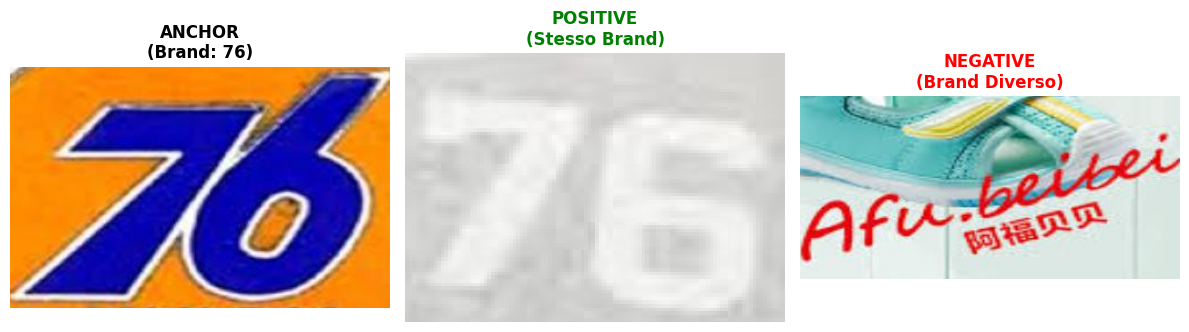

In [ ]:
# ==============================================================================
# --- CELLA DI TEST: VERIFICA FUNZIONAMENTO TRIPLET SAMPLER ---
# ==============================================================================

import matplotlib.pyplot as plt
import random

print("⏳ Avvio il test sul Triplet Sampler...")

try:
    # 1. Ricreiamo il dataset base per sicurezza (nel caso la cella precedente non sia in memoria)
    dataset_path = os.path.join(base_path, "LogoDet-3K")
    train_dataset = LogoDataset(root_dir=dataset_path, split="train", split_ratio=0.8)

    # 2. Avvolgiamo il dataset base nel nostro nuovo Triplet Sampler
    triplet_dataset = TripletLogoDataset(train_dataset)

    if len(triplet_dataset) > 0:
        # 3. Peschiamo un indice a caso
        idx = random.randint(0, len(triplet_dataset) - 1)

        # 4. Estraiamo la tripletta!
        anchor_img, positive_img, negative_img, anchor_label = triplet_dataset[idx]

        print(f"\n✅ Test Riuscito! Estrazione casuale della tripletta all'indice {idx}:")
        print(f"🏷️ Brand di riferimento (Anchor/Positive): {anchor_label}")

        # 5. Visualizziamo i risultati affiancati
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))

        # Anchor
        axes[0].imshow(anchor_img)
        axes[0].set_title(f"ANCHOR\n(Brand: {anchor_label})", fontweight='bold')
        axes[0].axis('off')

        # Positive
        axes[1].imshow(positive_img)
        axes[1].set_title(f"POSITIVE\n(Stesso Brand)", fontweight='bold', color='green')
        axes[1].axis('off')

        # Negative
        axes[2].imshow(negative_img)
        axes[2].set_title(f"NEGATIVE\n(Brand Diverso)", fontweight='bold', color='red')
        axes[2].axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print("\n⚠️ Errore: Il dataset risulta vuoto.")

except Exception as e:
    print(f"\n❌ Si è verificato un errore durante il test: {e}")

⏳ Avvio il test multiplo sul Triplet Sampler...


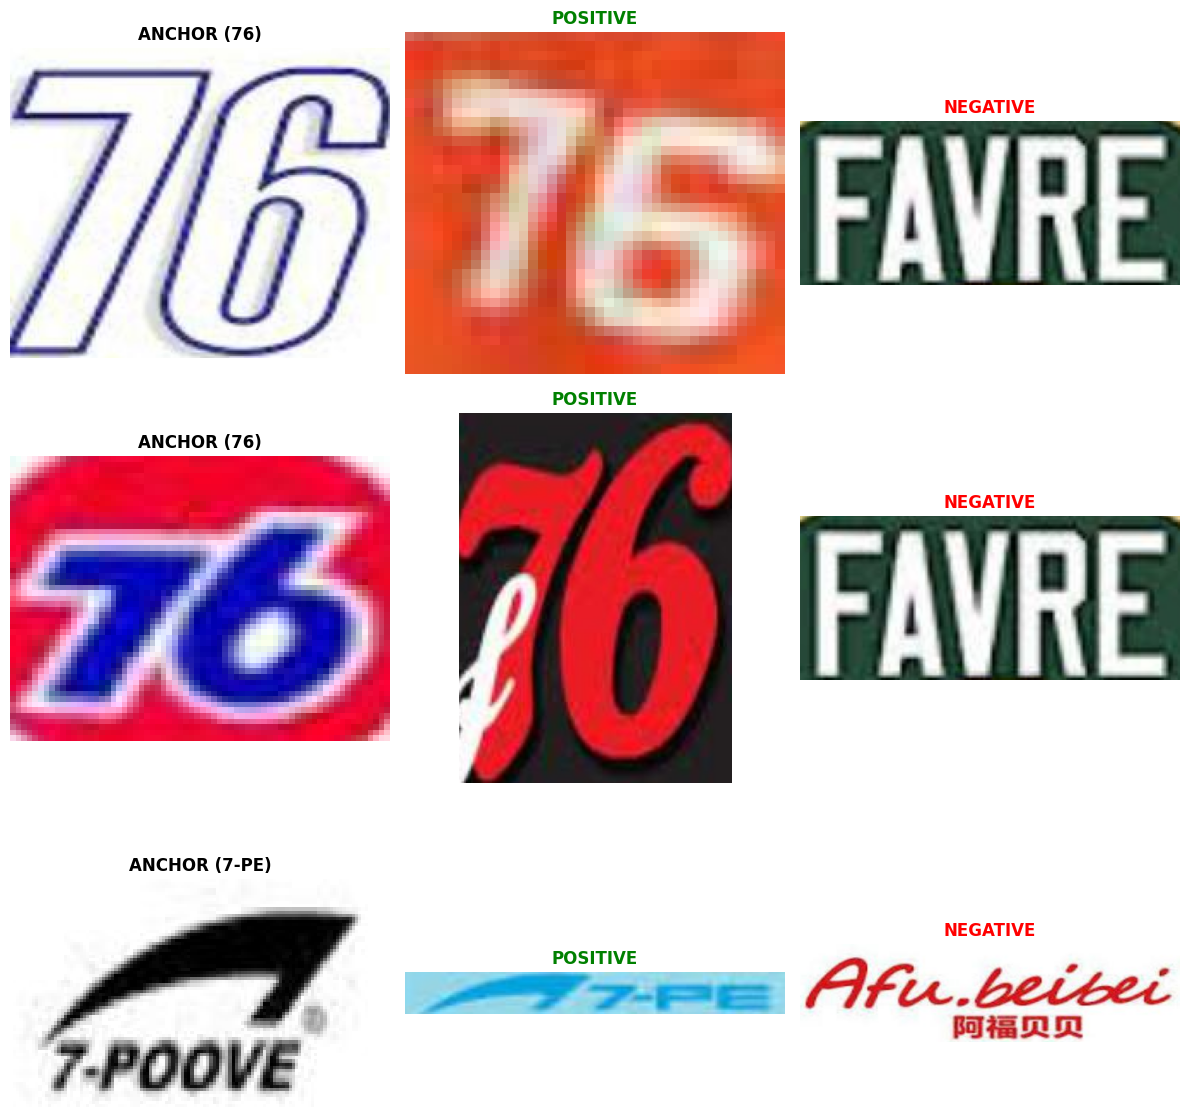

In [ ]:
# ==============================================================================
# --- CELLA DI TEST AVANZATA: VERIFICA MULTIPLA TRIPLET SAMPLER ---
# ==============================================================================

import matplotlib.pyplot as plt
import random
import time

print("⏳ Avvio il test multiplo sul Triplet Sampler...")

try:
    # 1. Per risparmiare memoria, ricarichiamo il dataset solo se non esiste già
    if 'triplet_dataset' not in locals():
        dataset_path = os.path.join(base_path, "LogoDet-3K")
        train_dataset = LogoDataset(root_dir=dataset_path, split="train", split_ratio=0.8)
        triplet_dataset = TripletLogoDataset(train_dataset)

    # 2. Sblocchiamo il seed globale per avere estrazioni VERAMENTE casuali a ogni run
    random.seed(time.time())

    # --- QUANTE TRIPLETTE VUOI VEDERE? ---
    num_esempi = 3
    # ------------------------------------

    if len(triplet_dataset) > 0:
        fig, axes = plt.subplots(num_esempi, 3, figsize=(12, 4 * num_esempi))

        for i in range(num_esempi):
            # Estrazione puramente casuale
            idx = random.randint(0, len(triplet_dataset) - 1)
            anchor_img, positive_img, negative_img, anchor_label = triplet_dataset[idx]

            # Disegniamo l'Anchor
            axes[i, 0].imshow(anchor_img)
            axes[i, 0].set_title(f"ANCHOR ({anchor_label})", fontweight='bold')
            axes[i, 0].axis('off')

            # Disegniamo il Positive
            axes[i, 1].imshow(positive_img)
            axes[i, 1].set_title(f"POSITIVE", fontweight='bold', color='green')
            axes[i, 1].axis('off')

            # Disegniamo il Negative
            axes[i, 2].imshow(negative_img)
            axes[i, 2].set_title(f"NEGATIVE", fontweight='bold', color='red')
            axes[i, 2].axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print("\n⚠️ Errore: Il dataset risulta vuoto.")

except Exception as e:
    print(f"\n❌ Si è verificato un errore durante il test: {e}")

In [ ]:
# ==============================================================================
# --- PARTE 1.3: SETUP DI VALUTAZIONE (Query vs Gallery per Test Set) ---
# ==============================================================================

from torch.utils.data import Subset
import random

def build_query_gallery(base_test_dataset):
    """
    Prende in input il dataset di test e lo divide in Query (1 immagine per brand)
    e Gallery (tutte le restanti immagini di quel brand).
    """
    print("⚙️ Generazione set Query vs Gallery in corso...")

    # 1. Raggruppiamo gli indici di tutte le immagini per brand
    label_to_indices = {}
    for idx, label in enumerate(base_test_dataset.labels):
        if label not in label_to_indices:
            label_to_indices[label] = []
        label_to_indices[label].append(idx)

    query_indices = []
    gallery_indices = []

    # 2. Applichiamo la logica 1-Shot per la valutazione
    for label, indices in label_to_indices.items():
        # Mescoliamo gli indici per non prendere sempre la prima immagine della cartella
        random.shuffle(indices)

        # Prendiamo 1 singola immagine come Query
        if len(indices) > 0:
            query_indices.append(indices[0])

        # Tutte le altre dello stesso brand finiscono nella Gallery
        if len(indices) > 1:
            gallery_indices.extend(indices[1:])

    # 3. Creiamo i Subset nativi di PyTorch
    query_dataset = Subset(base_test_dataset, query_indices)
    gallery_dataset = Subset(base_test_dataset, gallery_indices)

    print(f"✅ Setup completato con successo!")
    print(f"🔍 Immagini Query (Il 'Cerca'): {len(query_dataset)}")
    print(f"📚 Immagini Gallery (Il 'Database'): {len(gallery_dataset)}")

    return query_dataset, gallery_dataset

# --- TESTIAMO SUBITO LA FUNZIONE ---
try:
    print("\n⏳ Inizializzo il dataset di TEST per verificare...")
    # Creiamo il dataset in modalità "test" (prende il 20% di brand mai visti)
    dataset_path = os.path.join(base_path, "LogoDet-3K")
    test_dataset = LogoDataset(root_dir=dataset_path, split="test", split_ratio=0.8)

    # Dividiamolo in Query e Gallery
    query_set, gallery_set = build_query_gallery(test_dataset)

except Exception as e:
    print(f"\n❌ Errore durante il setup: {e}")


⏳ Inizializzo il dataset di TEST per verificare...
Inizializzazione LogoDataset in modalità: TEST...
Selezionati 2 brand per il set di test.
Caricamento completato: 158 immagini trovate.
⚙️ Generazione set Query vs Gallery in corso...
✅ Setup completato con successo!
🔍 Immagini Query (Il 'Cerca'): 2
📚 Immagini Gallery (Il 'Database'): 156


⏳ Avvio il test visivo su Query e Gallery...


/tmp/ipykernel_4278/89169528.py:44: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4278/89169528.py:44: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


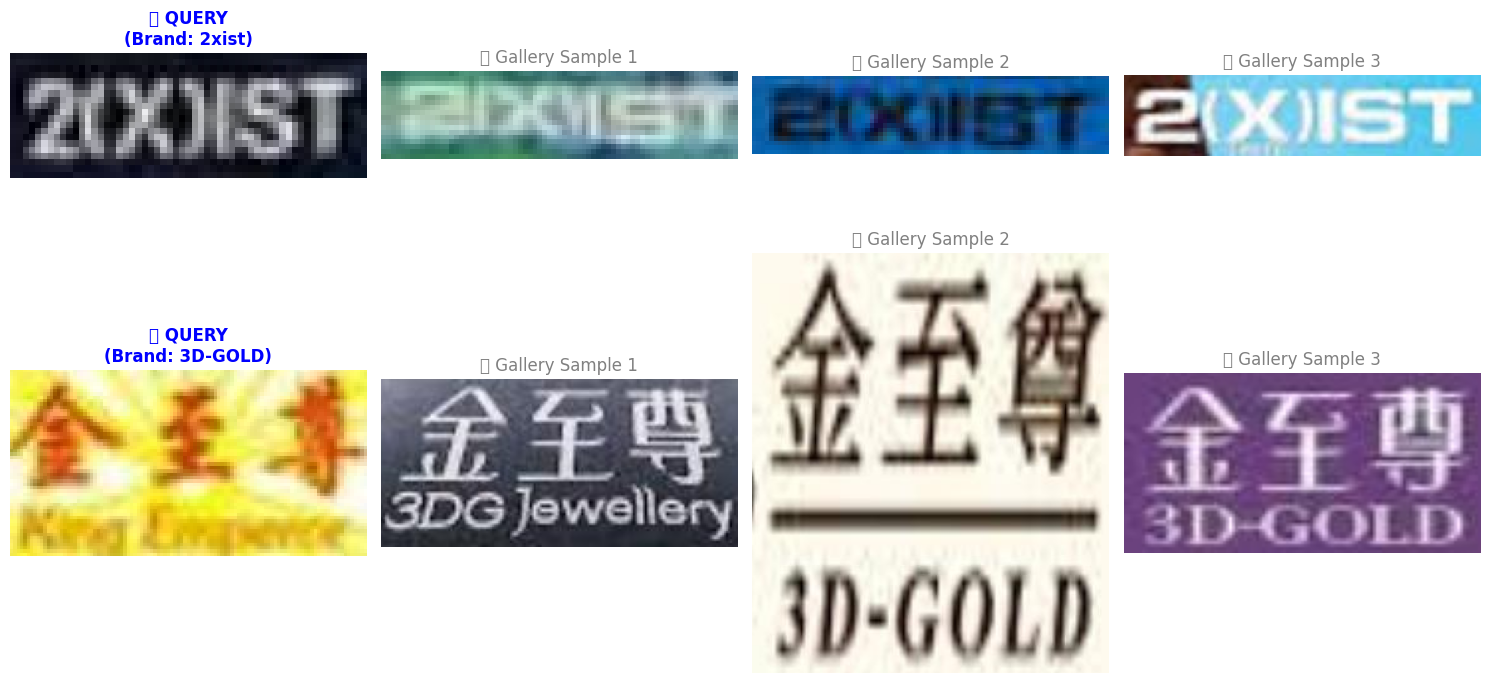

In [ ]:
# ==============================================================================
# --- CELLA DI TEST: VERIFICA VISIVA QUERY VS GALLERY ---
# ==============================================================================
import matplotlib.pyplot as plt

print("⏳ Avvio il test visivo su Query e Gallery...")

try:
    # Assumiamo che query_set e gallery_set siano già in memoria dalla cella precedente
    num_queries = len(query_set)

    # Prepariamo un plot dinamico in base a quante query abbiamo (nel tuo caso 2)
    fig, axes = plt.subplots(num_queries, 4, figsize=(15, 4 * num_queries))

    # Gestione caso limite per matplotlib
    if num_queries == 1:
        axes = [axes]

    for i in range(num_queries):
        # 1. Estraiamo la Query e la sua etichetta
        query_img, query_label = query_set[i]

        # Disegniamo la Query nella primissima colonna
        axes[i][0].imshow(query_img)
        axes[i][0].set_title(f"🔍 QUERY\n(Brand: {query_label})", fontweight='bold', color='blue')
        axes[i][0].axis('off')

        # 2. Andiamo a cercare 3 esempi corrispondenti "nascosti" nella Gallery
        gallery_samples = []
        for j in range(len(gallery_set)):
            g_img, g_label = gallery_set[j]
            if g_label == query_label:
                gallery_samples.append(g_img)
                if len(gallery_samples) == 3: # Ci bastano i primi 3 per la verifica visiva
                    break

        # 3. Disegniamo i sample della Gallery nelle colonne successive
        for k in range(3):
            if k < len(gallery_samples):
                axes[i][k+1].imshow(gallery_samples[k])
                axes[i][k+1].set_title(f"📚 Gallery Sample {k+1}", color='gray')
            axes[i][k+1].axis('off')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\n❌ Si è verificato un errore: {e}")

In [27]:
# ==============================================================================
# --- PARTE 1.4: DATASET DI ROBUSTEZZA (FlickrLogos32) ---
# ==============================================================================

class FlickrLogosDataset(Dataset):
    """
    Dataset per la valutazione della robustezza.
    Utilizza una pipeline di cropping per isolare il logo dal background.
    """
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.bboxes = []
        self.labels = []

        print(f"🔍 Esploro FlickrLogos32 in: {root_dir}")

        if os.path.exists(root_dir):
            # In FlickrLogos32 i brand sono solitamente cartelle dirette
            brands = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
            for brand in brands:
                brand_path = os.path.join(root_dir, brand)
                xml_files = glob.glob(os.path.join(brand_path, "*.xml"))

                for xml_file in xml_files:
                    try:
                        tree = ET.parse(xml_file)
                        root = tree.getroot()
                        bndbox = root.find('.//bndbox')
                        if bndbox is not None:
                            # Estrazione coordinate per il cropping
                            xmin = int(float(bndbox.find('xmin').text))
                            ymin = int(float(bndbox.find('ymin').text))
                            xmax = int(float(bndbox.find('xmax').text))
                            ymax = int(float(bndbox.find('ymax').text))

                            base_name = os.path.splitext(os.path.basename(xml_file))[0]
                            for ext in ['.jpg', '.png', '.jpeg']:
                                img_path = os.path.join(brand_path, base_name + ext)
                                if os.path.exists(img_path):
                                    self.image_paths.append(img_path)
                                    self.bboxes.append((xmin, ymin, xmax, ymax))
                                    self.labels.append(brand)
                                    break
                    except Exception:
                        continue

        print(f"✅ FlickrLogos32 pronto: {len(self.image_paths)} immagini caricate.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        bbox = self.bboxes[idx]
        label = self.labels[idx]
        img = crop_logo(img_path, bbox) # Funzione di utility definita prima
        if self.transform:
            img = self.transform(img)
        return img, label

# --- ATTIVAZIONE DATASET DI ROBUSTEZZA ---
# 1. Aggiorna il nome con quello esatto presente sul Drive
nome_cartella_flickr = "FlickrLogos32.v1i.voc"
flickr_path = os.path.join(base_path, nome_cartella_flickr)

print(f"🔍 Cerco il dataset in: {flickr_path}")

if os.path.exists(flickr_path):
    # 2. Inizializzazione del dataset di robustezza
    flickr_base = FlickrLogosDataset(root_dir=flickr_path)

    # 3. Creazione dei set Query e Gallery per i test
    flickr_query, flickr_gallery = build_query_gallery(flickr_base)

    print(f"✅ Successo! Caricate {len(flickr_query)} Query e {len(flickr_gallery)} immagini nella Gallery.")
else:
    print(f"❌ Errore persistente: Non trovo '{flickr_path}'.")
    print("Controlla che la cartella sia effettivamente dentro 'Progetto_ML_Team'.")

🔍 Cerco il dataset in: /content/drive/MyDrive/Progetto_ML_Team/FlickrLogos32.v1i.voc
🔍 Esploro FlickrLogos32 in: /content/drive/MyDrive/Progetto_ML_Team/FlickrLogos32.v1i.voc
✅ FlickrLogos32 pronto: 2237 immagini caricate.
⚙️ Generazione set Query vs Gallery in corso...
✅ Setup completato con successo!
🔍 Immagini Query (Il 'Cerca'): 3
📚 Immagini Gallery (Il 'Database'): 2234
✅ Successo! Caricate 3 Query e 2234 immagini nella Gallery.


In [ ]:
# ==============================================================================
# --- TEST DI CHIUSURA: VERIFICA ROBUSTEZZA ---
# ==============================================================================
import matplotlib.pyplot as plt
import random
import time

print("🚀 Lancio il test finale di generalizzazione...")
random.seed(time.time()) # Assicura un'immagine diversa a ogni esecuzione

if 'flickr_base' in locals() and len(flickr_base) > 0:
    idx = random.randint(0, len(flickr_base) - 1)
    img, label = flickr_base[idx]

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Test Robustezza: {label}\n(FlickrLogos32)", fontweight='bold')
    plt.axis('off')
    plt.show()

    print(f"\n✨ DB STATUS FINALE ✨")
    print(f"1. Training (LogoDet-3K): {len(train_dataset)} immagini pronte.")
    print(f"2. Test (LogoDet-3K): {len(query_set)} Query / {len(gallery_set)} Gallery.")
    print(f"3. Robustezza (FlickrLogos32): {len(flickr_query)} Query / {len(flickr_gallery)} Gallery.")
    print("\nLavoro Database: COMPLETATO. Prossimo passo: Architettura ResNet-50.")
else:
    print("⚠️ Dataset non caricato correttamente. Verifica i percorsi su Drive.")

🚀 Lancio il test finale di generalizzazione...
⚠️ Dataset non caricato correttamente. Verifica i percorsi su Drive.


⏳ Avvio il test di robustezza su FlickrLogos-32...

✅ Test Riuscito! Logo estratto da FlickrLogos-32:
🏷️ Brand: train
📏 Dimensioni: (208, 188)


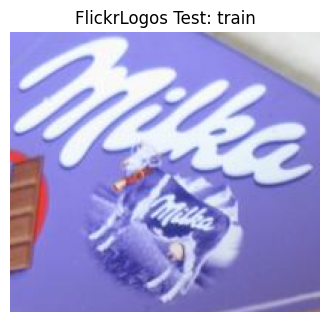


📊 Statistiche per le Metriche:
 - Query disponibili: 3
 - Gallery disponibile: 2234


In [ ]:
# ==============================================================================
# --- CELLA DI TEST FINALE: VERIFICA FLICKRLOGOS-32 (ROBUSTEZZA) ---
# ==============================================================================

import matplotlib.pyplot as plt
import random
import time

print("⏳ Avvio il test di robustezza su FlickrLogos-32...")

try:
    # Sblocchiamo il seed per vedere immagini sempre diverse
    random.seed(time.time())

    # 1. Verifichiamo se il dataset è stato caricato
    if 'flickr_base' in locals() and len(flickr_base) > 0:
        idx = random.randint(0, len(flickr_base) - 1)
        img, label = flickr_base[idx]

        print(f"\n✅ Test Riuscito! Logo estratto da FlickrLogos-32:")
        print(f"🏷️ Brand: {label}")
        print(f"📏 Dimensioni: {img.size}")

        # 2. Mostriamo il logo ritagliato
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.title(f"FlickrLogos Test: {label}")
        plt.axis('off')
        plt.show()

        # 3. Conferma Query/Gallery
        print(f"\n📊 Statistiche per le Metriche:")
        print(f" - Query disponibili: {len(flickr_query)}")
        print(f" - Gallery disponibile: {len(flickr_gallery)}")

    else:
        print("\n⚠️ Attenzione: Dataset FlickrLogos non trovato. Assicurati che la cartella sia su Drive.")

except Exception as e:
    print(f"\n❌ Errore durante il test finale: {e}")

In [ ]:
# =========================================================================
# ============= ARCHITETTURA ==============================================
# =========================================================================

## Import and setup

import torch
# Library that contains ImageNet weigths
import torch.nn as nn
# Library for normalization
import torch.nn.functional as F
# Library for optimization
import torch.optim as optim
# Library that contains resnet50
from torchvision import models

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
## Model Architecture

class LogoNet(nn.Module):
  def __init__(self):
    super(LogoNet, self).__init__()

    # Load the ResNet50 backbone  with  weights  pre-trained  on  ImageNet
    self.backbone = models.resnet50(weights='IMAGENET1K_V1')

    # Replace the final layer (fc) to output 2048-dimensional vector
    # Compute number of features
    num_features = self.backbone.fc.in_features
    # Set up the fc layer
    self.backbone.fc = nn.Linear(num_features, 2048)

  def forward(self, x):
    # Generate the embedding
    embedding = self.backbone(x)
    # Apply L2 normalization (needed for a stable Triplet Loss)
    return F.normalize(embedding, p=2, dim=1)

# Inizilization of the model
model = LogoNet().to(device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 165MB/s]


In [ ]:
## Triplet Loss and Optimizer

# Define Tripleto Loss
# Margin set to 0.2
# Source: FaceNet: A Unified Embedding for Face Recognition and Clustering
loss_function = nn.TripletMarginLoss(margin=0.2, p=2)

# Define optimizer
# LR 0.00025 for balanced speed and stability
# Weigth decay 0.001 for preventing the model from overfitting on LogoDet-3K
# Source: A Deep Siamese ResNet-50 Framework with Triplet
# loss for High-Precision Face Verication
optimizer = optim.Adam(model.parameters(), lr=0.00025, weight_decay=0.001)

In [ ]:
## Training simulation (Dummy Test)

# Simulate 10 triplets
# Dimensions: [Batch Size, RGB Channels, Height, Width]
anchor_dummy = torch.randn(10, 3, 224, 224).to(device)
positive_dummy = torch.randn(10, 3, 224, 224).to(device)
negative_dummy = torch.randn(10, 3, 224, 224).to(device)

# Active training mode
model.train();
# Buffers reset
optimizer.zero_grad();

# Generate embeddings
anchor_embedding = model(anchor_dummy)
positive_embedding = model(positive_dummy)
negative_embedding = model(negative_dummy)

# Calculate Loss based on the Margin
loss = loss_function(anchor_embedding, positive_embedding, negative_embedding)

# Backpropagation
loss.backward()
# Update weights
optimizer.step()

print("--- Simulation Complete ---")
print(f"Final Loss Value: {loss.item():.4f}")
print(f"Embedding Shape: {anchor_embedding.shape}")

--- Simulation Complete ---
Final Loss Value: 0.1836
Embedding Shape: torch.Size([10, 2048])


In [ ]:
## Episodic Training

def train_one_epoch(model, dataloader, optimizer, loss_function, device):
  # Active training mode
  model.train();
  # Reset running loss at the beginning of an epoch
  running_loss = 0.0;

  for batch_index, (anchor, positive, negative) in enumerate(dataloader):
    # Move to GPU
    anchor = anchor.to(device)
    positive = positive.to(device)
    negative = negative.to(device)

    # Reset gradients
    optimizer.zero_grad()

    # Forward Pass
    anchor_embedding = model(anchor)
    positive_embedding = model(positive)
    negative_embedding = model(negative)

    # Calculate Loss based on the Margin
    loss = loss_function(anchor_embedding, positive_embedding, negative_embedding)

    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()

    # Update running loss
    running_loss += loss

    if batch_index % 10 == 0:
      print(f"Batch {batch_index} Loss: {loss.item():.4f}")

  return running_loss / len(dataloader)




In [ ]:
#TRAINING

from torch.utils.data import DataLoader
from torchvision import transforms

# Trasform per train (puoi riusarli per test, con meno augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Dataset base train
dataset_path = os.path.join(base_path, "LogoDet-3K")
train_base = LogoDataset(root_dir=dataset_path,
                         split="train",
                         split_ratio=0.8,
                         transform=train_transform)

# Triplet dataset + dataloader
triplet_dataset = TripletLogoDataset(train_base)

train_loader = DataLoader(triplet_dataset,
                          batch_size=32,
                          shuffle=True,
                          num_workers=2,
                          pin_memory=True)

def train_one_epoch(model, dataloader, optimizer, loss_function, device):
    model.train()
    running_loss = 0.0
    for batch_idx, (anchor, positive, negative, _) in enumerate(dataloader):
        anchor = anchor.to(device)
        positive = positive.to(device)
        negative = negative.to(device)

        optimizer.zero_grad()
        anc_emb = model(anchor)
        pos_emb = model(positive)
        neg_emb = model(negative)

        loss = loss_function(anc_emb, pos_emb, neg_emb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if batch_idx % 10 == 0:
            print(f"[Batch {batch_idx:04d}] Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(dataloader)
    print(f"Epoch finished. Avg loss: {epoch_loss:.4f}")
    return epoch_loss

# Loop di training
n_epochs = 5  # o più, se la GPU regge
for epoch in range(n_epochs):
    print(f"\n===== Epoch {epoch+1}/{n_epochs} =====")
    train_one_epoch(model, train_loader, optimizer, loss_function, device)

# Salva i pesi nel file che poi userai nell'eval
torch.save(model.state_dict(), "logonet_triplet.pth")
print("✅ Modello salvato in logonet_triplet.pth")


Inizializzazione LogoDataset in modalità: TRAIN...
Selezionati 7 brand per il set di train.
Caricamento completato: 682 immagini trovate.
⚙️ Inizializzazione Triplet Sampler...
✅ Sampler pronto: indicizzati 7 brand univoci.

===== Epoch 1/5 =====
[Batch 0000] Loss: 0.1815
[Batch 0010] Loss: 0.0457
[Batch 0020] Loss: 0.0160
Epoch finished. Avg loss: 0.0663

===== Epoch 2/5 =====
[Batch 0000] Loss: 0.0283
[Batch 0010] Loss: 0.0312
[Batch 0020] Loss: 0.0361
Epoch finished. Avg loss: 0.0357

===== Epoch 3/5 =====
[Batch 0000] Loss: 0.0483
[Batch 0010] Loss: 0.0499
[Batch 0020] Loss: 0.0008
Epoch finished. Avg loss: 0.0214

===== Epoch 4/5 =====
[Batch 0000] Loss: 0.0040
[Batch 0010] Loss: 0.0252
[Batch 0020] Loss: 0.0164
Epoch finished. Avg loss: 0.0163

===== Epoch 5/5 =====
[Batch 0000] Loss: 0.0014
[Batch 0010] Loss: 0.0062
[Batch 0020] Loss: 0.0202
Epoch finished. Avg loss: 0.0149
✅ Modello salvato in logonet_triplet.pth


In [30]:
# ============================================================
# =============  EVAL FINALE: RETRIEVAL + METRICHE ===========
# ============================================================
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
import numpy as np
import os

print("\n===== INIZIO VALUTAZIONE FINALE =====")

# --- 1) Trasformazioni per il test (coerenti con ResNet) ---
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# --- 2) Ricrea dataset di test LogoDet-3K + Query/Gallery ---
dataset_path = os.path.join(base_path, "LogoDet-3K")
print("\n[LOGODET-3K] Inizializzo il dataset di TEST...")
test_base = LogoDataset(root_dir=dataset_path,
                        split="test",
                        split_ratio=0.8,
                        transform=test_transform)

query_set, gallery_set = build_query_gallery(test_base)

print(f"[LOGODET-3K] Query:  {len(query_set)} immagini")
print(f"[LOGODET-3K] Gallery: {len(gallery_set)} immagini")

query_loader = DataLoader(query_set, batch_size=32,
                          shuffle=False, num_workers=2, pin_memory=True)
gallery_loader = DataLoader(gallery_set, batch_size=32,
                            shuffle=False, num_workers=2, pin_memory=True)

# --- 3) Funzione per calcolare gli embedding ---
@torch.no_grad()
def compute_embeddings(model, loader, device):
    model.eval()
    all_embs = []
    all_labels = []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        embs = model(imgs).cpu()
        all_embs.append(embs)
        # Gestione etichette come stringhe
        all_labels.extend(labels)

    return torch.cat(all_embs, dim=0), np.array(all_labels)

# --- 4) Funzione metriche 1-query-vs-gallery ---
@torch.no_grad()
def retrieval_metrics_1query_vs_gallery(q_embs, q_labels,
                                        g_embs, g_labels,
                                        Ks=(1, 5, 10)):
    q_embs = F.normalize(q_embs, p=2, dim=1)
    g_embs = F.normalize(g_embs, p=2, dim=1)

    sim = q_embs @ g_embs.t()   # (Nq, Ng)

    P = {K: [] for K in Ks}
    R = {K: [] for K in Ks}

    for i in range(q_embs.size(0)):
        y = q_labels[i]
        order = torch.argsort(sim[i], descending=True).numpy()
        ordered_labels = g_labels[order]

        rel = (ordered_labels == y).astype(np.float32)

        for K in Ks:
            topk = rel[:K]
            P[K].append(topk.mean().item())
            R[K].append(1.0 if topk.sum().item() > 0 else 0.0)

    Pm = {K: sum(P[K]) / len(P[K]) for K in Ks}
    Rm = {K: sum(R[K]) / len(R[K]) for K in Ks}
    return Pm, Rm

# --- 5) Carica i pesi del modello addestrato ---
print("\nCarico i pesi salvati del modello (logonet_triplet.pth)...")
if os.path.exists("logonet_triplet.pth"):
    model.load_state_dict(torch.load("logonet_triplet.pth", map_location=device))
else:
    print("\u26a0\ufe0f ATTENZIONE: File pesi non trovato, uso il modello corrente.")
model.to(device)

# --- 6) Embedding per LogoDet-3K (test) ---
print("\n[LOGODET-3K] Calcolo embeddings per Query e Gallery...")
q_embs, q_labels = compute_embeddings(model, query_loader, device)
g_embs, g_labels = compute_embeddings(model, gallery_loader, device)

Ks = (1, 5, 10)
P_at_K, R_at_K = retrieval_metrics_1query_vs_gallery(
    q_embs, q_labels, g_embs, g_labels, Ks=Ks
)

print("\n===== RISULTATI LOGODET-3K (TEST) =====")
for K in Ks:
    print(f"P@{K}: {P_at_K[K]:.4f}  |  R@{K}: {R_at_K[K]:.4f}")

print("\n\u2705 VALUTAZIONE FINALE COMPLETATA.")


===== INIZIO VALUTAZIONE FINALE =====

[LOGODET-3K] Inizializzo il dataset di TEST...
Inizializzazione LogoDataset in modalità: TEST...
Selezionati 2 brand per il set di test.
Caricamento completato: 158 immagini trovate.
⚙️ Generazione set Query vs Gallery in corso...
✅ Setup completato con successo!
🔍 Immagini Query (Il 'Cerca'): 2
📚 Immagini Gallery (Il 'Database'): 156
[LOGODET-3K] Query:  2 immagini
[LOGODET-3K] Gallery: 156 immagini

Carico i pesi salvati del modello (logonet_triplet.pth)...

[LOGODET-3K] Calcolo embeddings per Query e Gallery...
DEBUG - Shape q_embs: torch.Size([2, 2048])
DEBUG - Shape g_embs: torch.Size([156, 2048])
DEBUG - Prime 3 query labels: ['2xist' '3D-GOLD']
DEBUG - Prime 3 gallery labels: ['2xist' '2xist' '2xist']
DEBUG - Esempio query label vs gallery matches: 70

===== RISULTATI LOGODET-3K (TEST) =====
P@1: 1.0000  |  R@1: 1.0000
P@5: 0.9000  |  R@5: 1.0000
P@10: 0.7500  |  R@10: 1.0000

✅ VALUTAZIONE FINALE COMPLETATA.


In [31]:
# Baseline senza triplet training
model_vanilla = LogoNet().to(device)  # Pesi ImageNet puri
model_vanilla.eval()

q_vanilla, _ = compute_embeddings(model_vanilla, query_loader, device)
g_vanilla, _ = compute_embeddings(model_vanilla, gallery_loader, device)

P_vanilla, R_vanilla = retrieval_metrics_1query_vs_gallery(
    q_vanilla, q_labels, g_vanilla, g_labels, Ks=Ks
)

print("\n===== BASELINE VANILLA =====")
for K in (1,5,10):
    print(f"P@{K}: {P_vanilla[K]:.4f}")



===== BASELINE VANILLA =====
P@1: 1.0000
P@5: 0.9000
P@10: 0.8000
